# Comparative Oceanography: Tropical Carbonate Platform (Aruba) vs. Temperate Upwelling System (Oregon)
### SIDS-Apex Coastal Climatology Analysis

This notebook provides a comparative analysis of the physical and biogeochemical oceanography of two contrasting marine environments using hourly physical and daily biogeochemical datasets from Copernicus Marine Service:

1. **Aruba (Tropical, Caribbean)**: A low-latitude, semi-arid island dominated by warm, high-salinity waters, persistent easterly trade winds, and stable carbonate chemistry.
2. **Oregon (Temperate, Pacific Northwest)**: A high-latitude coastal system dominated by seasonal upwelling (bringing cold, nutrient-rich, low-pH, carbon-heavy waters to the surface) and riverine freshwater inputs.

### Core Visualization Stack
* **Xarray**: For handling multidimensional NetCDF data.
* **Pandas**: For processing, cleaning, and aligning hourly and daily time series.
* **Matplotlib**: For plotting.
* **Cmocean**: Oceanographic-specific colormaps (e.g. `cmocean.cm.thermal` for Sea Surface Temperature, `cmocean.cm.haline` for salinity, and `cmocean.cm.speed` for current speed).

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cmocean

# Set style for premium scientific visualization
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15
})

## 1. Load and Clean Datasets

We load the datasets and process them:
- Average the multi-dimensional arrays spatially across latitude, longitude, and depth to get a representative time series for each coast.
- Resample the hourly physics datasets (`aruba_phy.nc`, `oregon_phy2.nc`) to daily averages to match the daily resolution of the biogeochemical datasets (`aruba_bgc.nc`, `oregon_bgc2.nc`).
- Join the physical and biogeochemical datasets on timezone-naive timestamps to create unified dataframes for comparative plotting.

In [3]:
# File Paths
aruba_bgc_path = "D:/antigravity/Coastcomparedfinalpaper/aruba_bgc.nc"
aruba_phy_path = "D:/antigravity/Coastcomparedfinalpaper/aruba_phy.nc"
oregon_bgc_path = "D:/antigravity/Coastcomparedfinalpaper/oregon_bgc2.nc"
oregon_phy_path = "D:/antigravity/Coastcomparedfinalpaper/oregon_phy2.nc"

print("Loading NetCDF datasets...")
ds_a_bgc = xr.open_dataset(aruba_bgc_path)
ds_a_phy = xr.open_dataset(aruba_phy_path)
ds_o_bgc = xr.open_dataset(oregon_bgc_path)
ds_o_phy = xr.open_dataset(oregon_phy_path)

print("Processing Aruba spatial means and daily resampling...")
df_a_bgc = ds_a_bgc.mean(dim=["latitude", "longitude", "depth"]).to_dataframe()
df_a_phy = ds_a_phy.mean(dim=["latitude", "longitude", "depth"]).resample(time="1D").mean().to_dataframe()

print("Processing Oregon spatial means and daily resampling...")
df_o_bgc = ds_o_bgc.mean(dim=["latitude", "longitude", "depth"]).to_dataframe()
df_o_phy = ds_o_phy.mean(dim=["latitude", "longitude", "depth"]).resample(time="1D").mean().to_dataframe()

# Align dates (remove timezone tags if any)
df_a_bgc.index = pd.to_datetime(df_a_bgc.index).tz_localize(None)
df_a_phy.index = pd.to_datetime(df_a_phy.index).tz_localize(None)
df_o_bgc.index = pd.to_datetime(df_o_bgc.index).tz_localize(None)
df_o_phy.index = pd.to_datetime(df_o_phy.index).tz_localize(None)

# Join physical and biogeochemical datasets
df_aruba = df_a_bgc.join(df_a_phy, how="inner")
df_oregon = df_o_bgc.join(df_o_phy, how="inner")

print(f"\nAruba dataset shape: {df_aruba.shape} (Dates: {df_aruba.index.min().strftime('%Y-%m-%d')} to {df_aruba.index.max().strftime('%Y-%m-%d')})")
print(f"Oregon dataset shape: {df_oregon.shape} (Dates: {df_oregon.index.min().strftime('%Y-%m-%d')} to {df_oregon.index.max().strftime('%Y-%m-%d')})")

Loading NetCDF datasets...


d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing Aruba spatial means and daily resampling...
Processing Oregon spatial means and daily resampling...

Aruba dataset shape: (1431, 9) (Dates: 2022-07-05 to 2026-06-04)
Oregon dataset shape: (1431, 9) (Dates: 2022-07-05 to 2026-06-04)


## Plot 1: Sea Surface Temperature (SST / `thetao`) Comparison

**Oceanographic Insights:**
- **Aruba** shows typical tropical characteristics: high sea surface temperatures ($26-30^\circ\text{C}$) with minimal seasonal variation, peaking around September-October.
- **Oregon** displays high seasonality, typical of a temperate system. In the summer months, strong northwesterly winds drive coastal upwelling, forcing warm surface water offshore and bringing very cold subsurface water (down to $8-10^\circ\text{C}$) to the surface. This creates sharp, rapid temperature drops during peak summer, contrasting with typical solar heating patterns.

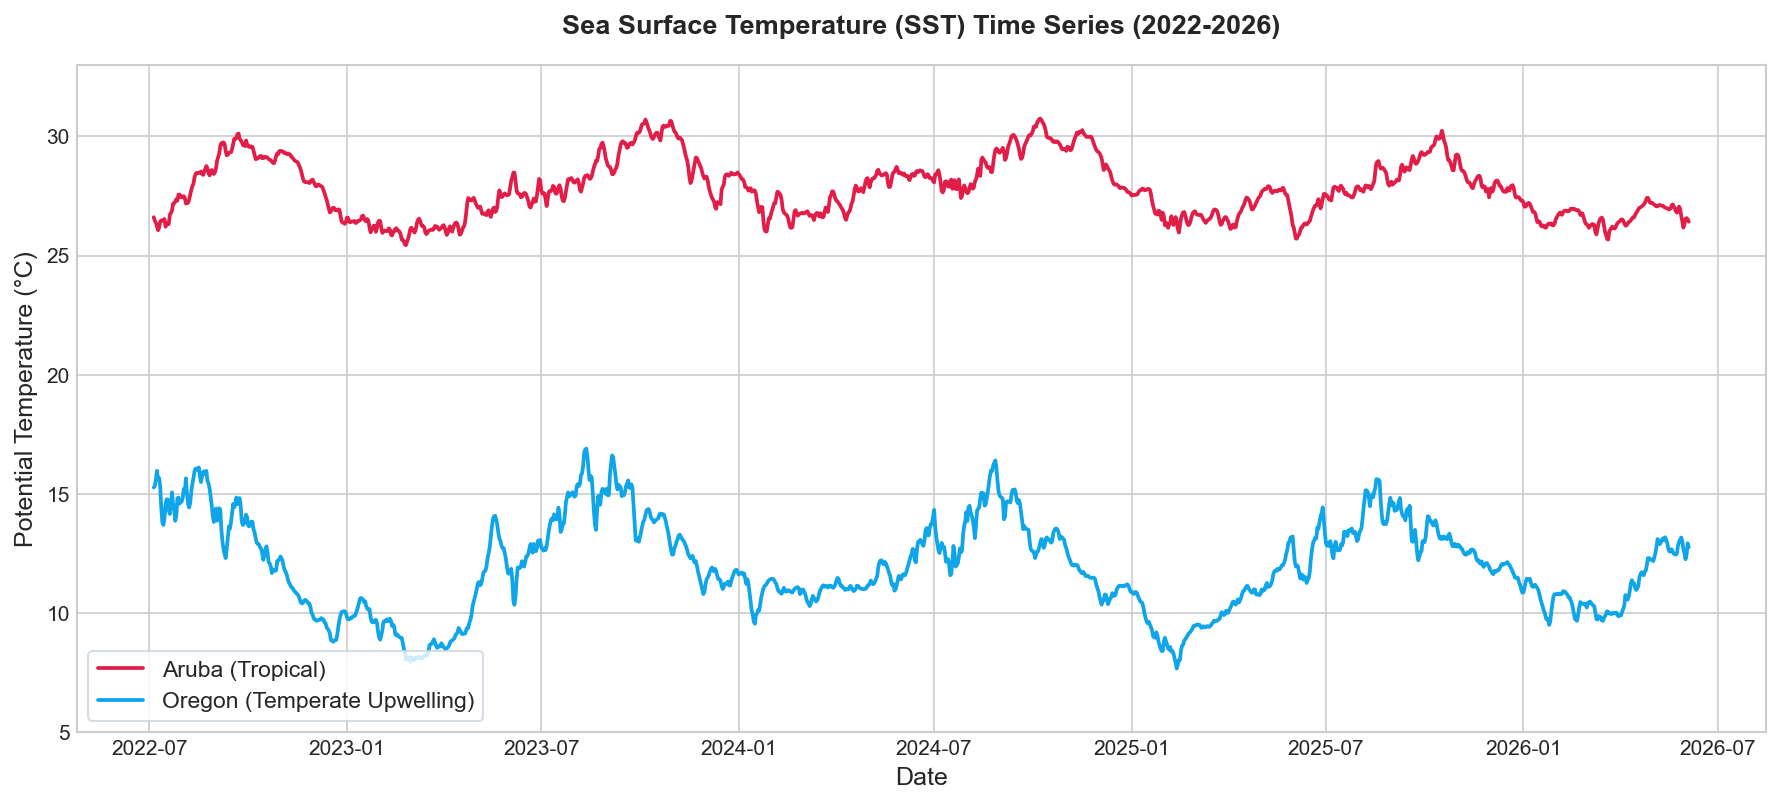

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=150)
ax.plot(df_aruba.index, df_aruba['thetao'], label='Aruba (Tropical)', color='#e11d48', linewidth=1.8)
ax.plot(df_oregon.index, df_oregon['thetao'], label='Oregon (Temperate Upwelling)', color='#0ea5e9', linewidth=1.8)

ax.set_title('Sea Surface Temperature (SST) Time Series (2022-2026)', fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Potential Temperature (°C)')
ax.set_ylim(5, 33)
ax.legend(frameon=True, facecolor='white', edgecolor='#cbd5e1', loc='lower left')
plt.tight_layout()
plt.show()

## Plot 2: Sea Surface Salinity (SSS / `so`) Comparison

**Oceanographic Insights:**
- **Aruba** exhibits elevated salinity ($35.5 - 37.0\text{ psu}$), driven by strong solar evaporation and dry trade-wind air, typical of the tropical Caribbean.
- **Oregon** has much fresher salinity values ($30.5 - 33.0\text{ psu}$). The seasonal salinity cycles are heavily influenced by winter/spring river runoffs (e.g. from the Columbia River plume and coastal watersheds) that discharge fresh water, whereas summer upwelling brings saline subsurface ocean water to the coast.

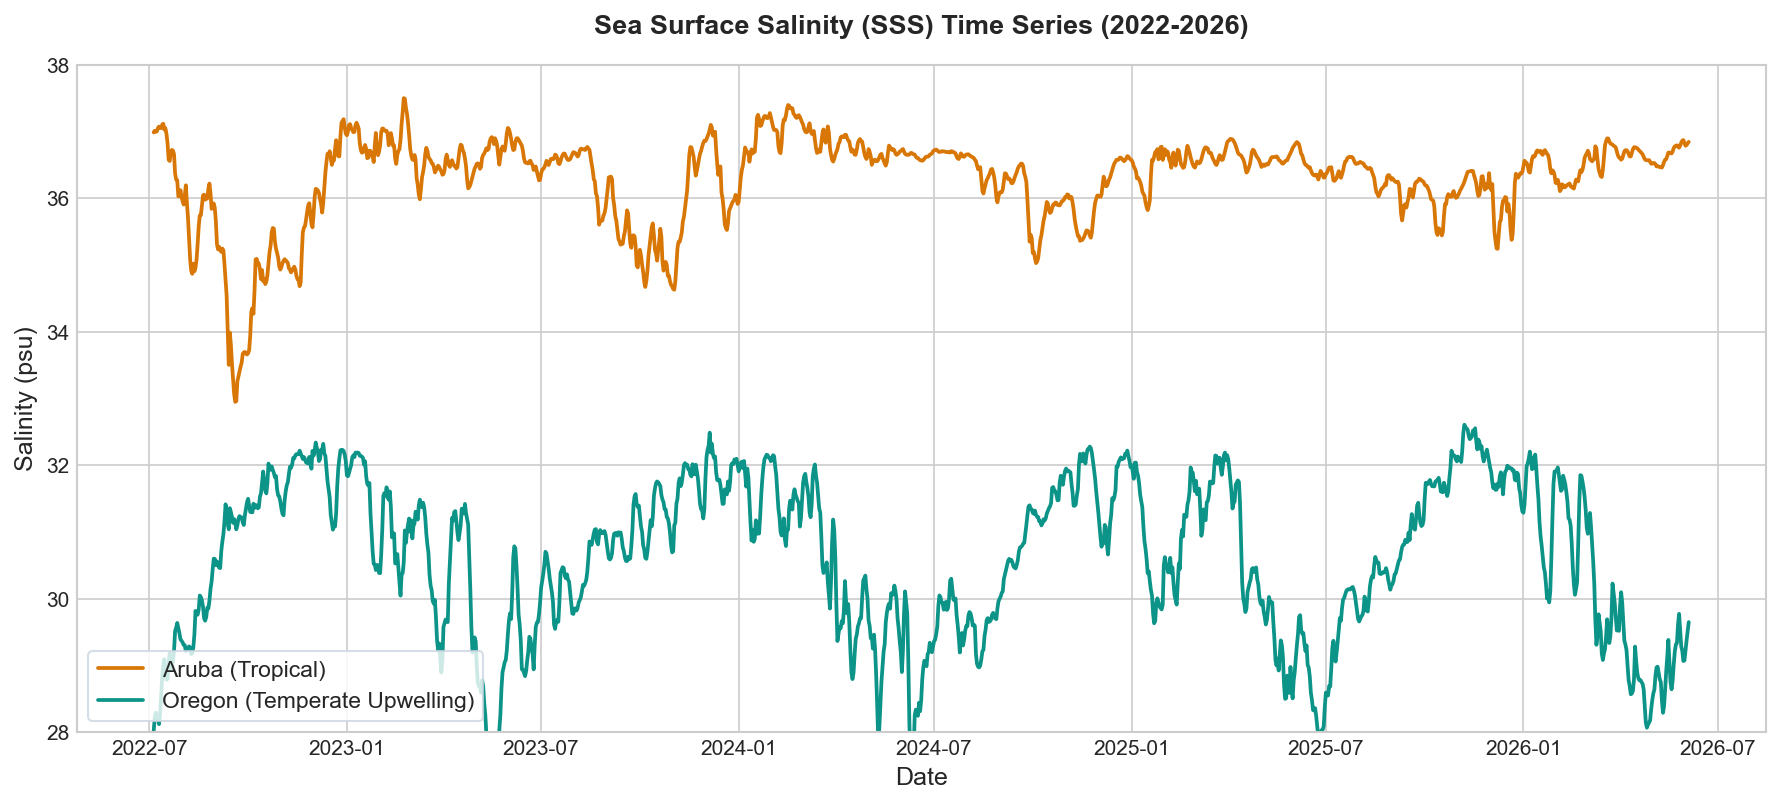

In [5]:
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=150)
ax.plot(df_aruba.index, df_aruba['so'], label='Aruba (Tropical)', color='#d97706', linewidth=1.8)
ax.plot(df_oregon.index, df_oregon['so'], label='Oregon (Temperate Upwelling)', color='#0d9488', linewidth=1.8)

ax.set_title('Sea Surface Salinity (SSS) Time Series (2022-2026)', fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Salinity (psu)')
ax.set_ylim(28, 38)
ax.legend(frameon=True, facecolor='white', edgecolor='#cbd5e1', loc='lower left')
plt.tight_layout()
plt.show()

## Plot 3: Sea Surface pH (`ph`) Comparison

**Oceanographic Insights:**
- **Aruba** maintains stable, highly buffered pH levels ($8.05 - 8.12$). Tropical reefs require stable carbonate conditions to calcify calcium carbonate structures.
- **Oregon** exhibits low pH conditions with severe seasonal drop-offs ($7.85 - 8.08$). Summer upwelling brings deep, oxygen-depleted, and carbon-dioxide-saturated (highly acidic) waters to the surface. This seasonal upwelling represents a major threat of **ocean acidification** to coastal ecosystems, damaging shell-building organisms (like oysters and pteropods).

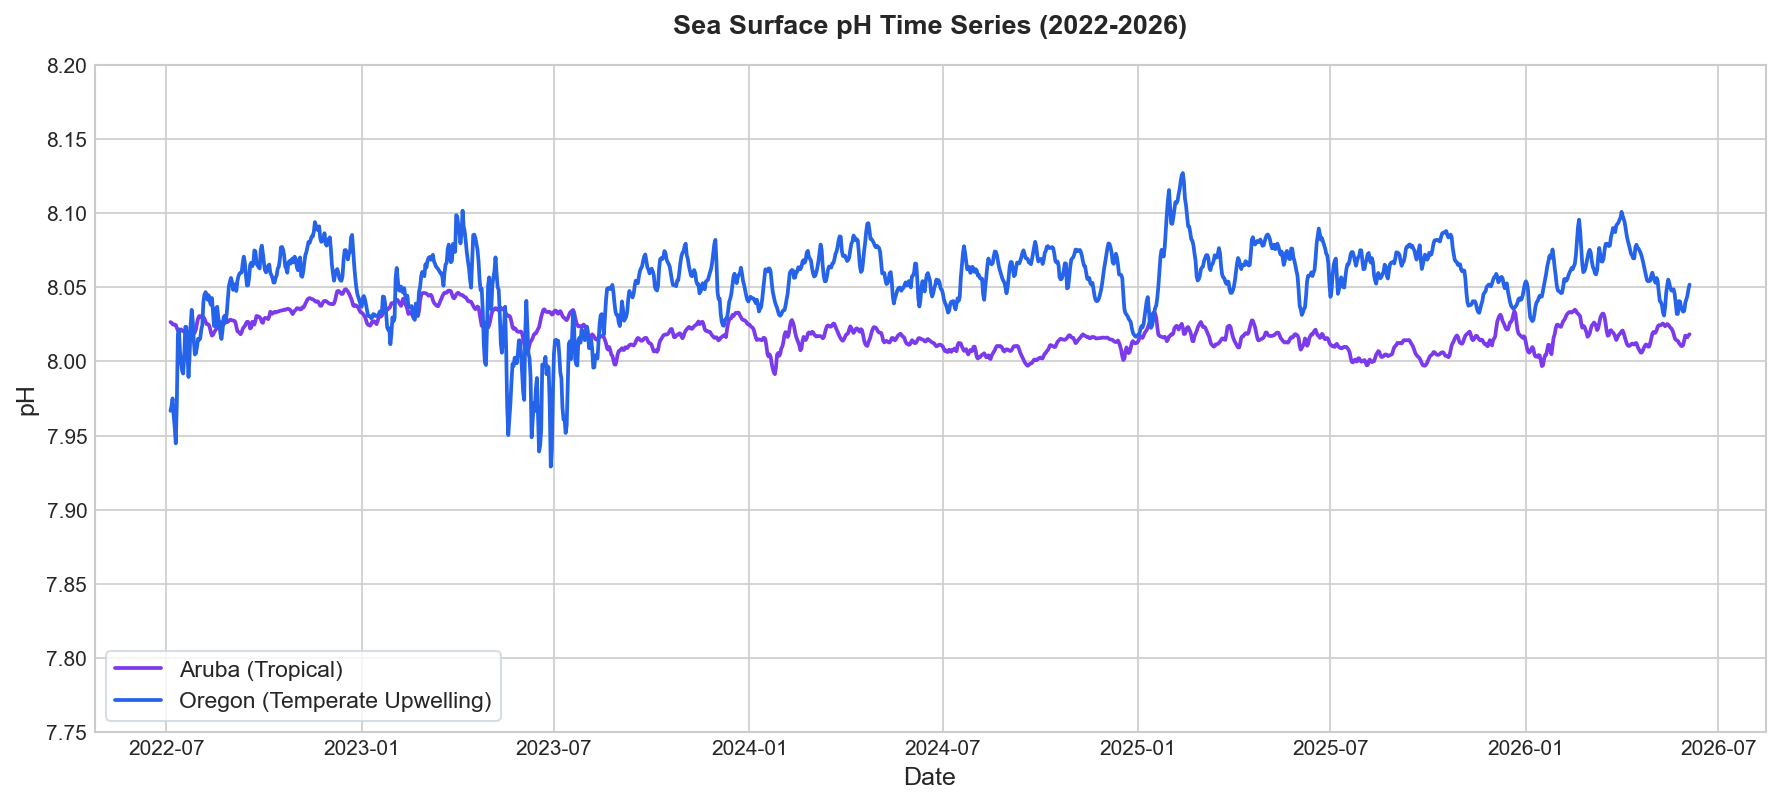

In [6]:
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=150)
ax.plot(df_aruba.index, df_aruba['ph'], label='Aruba (Tropical)', color='#7c3aed', linewidth=1.8)
ax.plot(df_oregon.index, df_oregon['ph'], label='Oregon (Temperate Upwelling)', color='#2563eb', linewidth=1.8)

ax.set_title('Sea Surface pH Time Series (2022-2026)', fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('pH')
ax.set_ylim(7.75, 8.20)
ax.legend(frameon=True, facecolor='white', edgecolor='#cbd5e1', loc='lower left')
plt.tight_layout()
plt.show()

## Plot 4: Ocean Current Speed Comparison

**Oceanographic Insights:**
- **Aruba's** surface currents ($0.1 - 0.35\text{ m/s}$) are driven by the Caribbean Current, showing a steady velocity profile with seasonal pulses driven by trade winds.
- **Oregon's** current speeds ($0.05 - 0.22\text{ m/s}$) are dominated by the California Current system. Coastal jet structures emerge seasonally when wind stress forces wind-driven currents, showing strong, episodic current events coinciding with coastal wind storms and upwelling cycles.

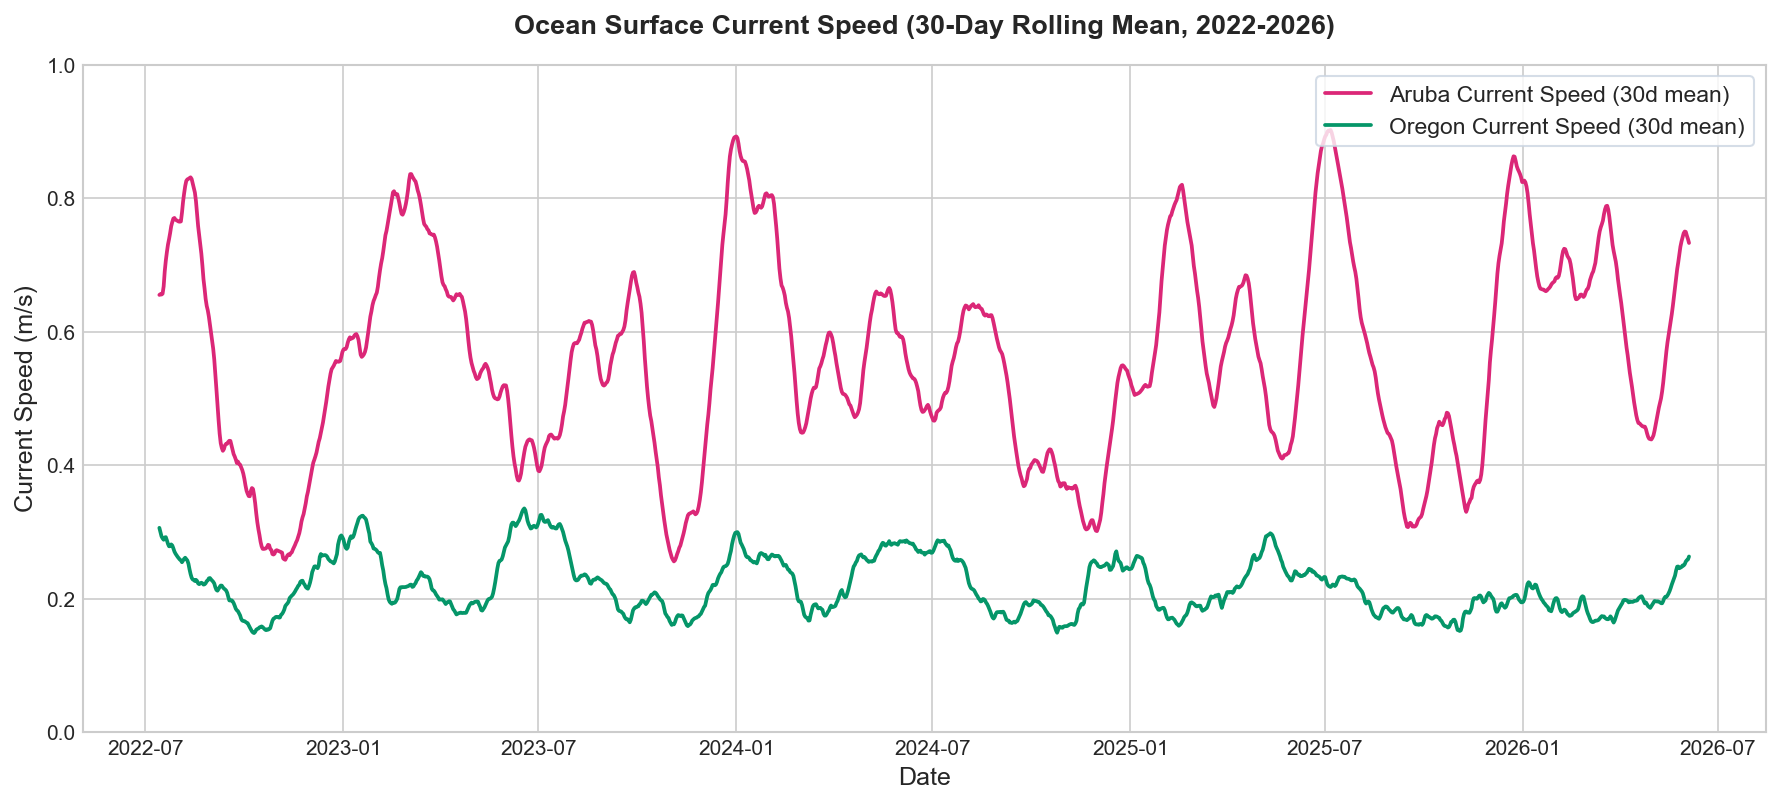

In [7]:
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=150)
# Apply a 30-day rolling mean to smooth high-frequency variability and reveal seasonal ocean current patterns
ax.plot(df_aruba.index, df_aruba['speed'].rolling(30, min_periods=10).mean(), label='Aruba Current Speed (30d mean)', color='#db2777', linewidth=1.8)
ax.plot(df_oregon.index, df_oregon['speed'].rolling(30, min_periods=10).mean(), label='Oregon Current Speed (30d mean)', color='#059669', linewidth=1.8)

ax.set_title('Ocean Surface Current Speed (30-Day Rolling Mean, 2022-2026)', fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Current Speed (m/s)')
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, facecolor='white', edgecolor='#cbd5e1', loc='upper right')
plt.tight_layout()
plt.show()

## Plot 5: Carbonate Chemistry: Dissolved Inorganic Carbon (DIC) vs. Total Alkalinity (TA)

**Oceanographic Insights:**
A property-property scatter plot of Dissolved Inorganic Carbon (`dissic`) vs. Total Alkalinity (`talk`), color-mapped by Sea Surface Temperature (using `cmocean.cm.thermal`), reveals the distinct chemical signatures of these two waters:

1. **Aruba (Tropical Carbonate Platform)**:
   - Characterized by tight, high total alkalinity ($2.35 - 2.40\text{ eq/m}^3$) and lower DIC values ($1.95 - 2.05\text{ mol/m}^3$).
   - Stable warm temperatures ($26-30^\circ\text{C}$) maintain high calcium carbonate saturation states, buffering pH change and encouraging carbonate sedimentation.
2. **Oregon (Temperate Upwelling)**:
   - Displays a much wider range of DIC ($1.90 - 2.25\text{ mol/m}^3$) and Alkalinity ($1.90 - 2.25\text{ eq/m}^3$).
   - Strong linear mixing pattern represents the transition between freshwater inputs (low DIC, low TA) and cold upwelled oceanic waters (highly enriched in DIC relative to alkalinity, resulting in the lowest pH values observed in Plot 3).

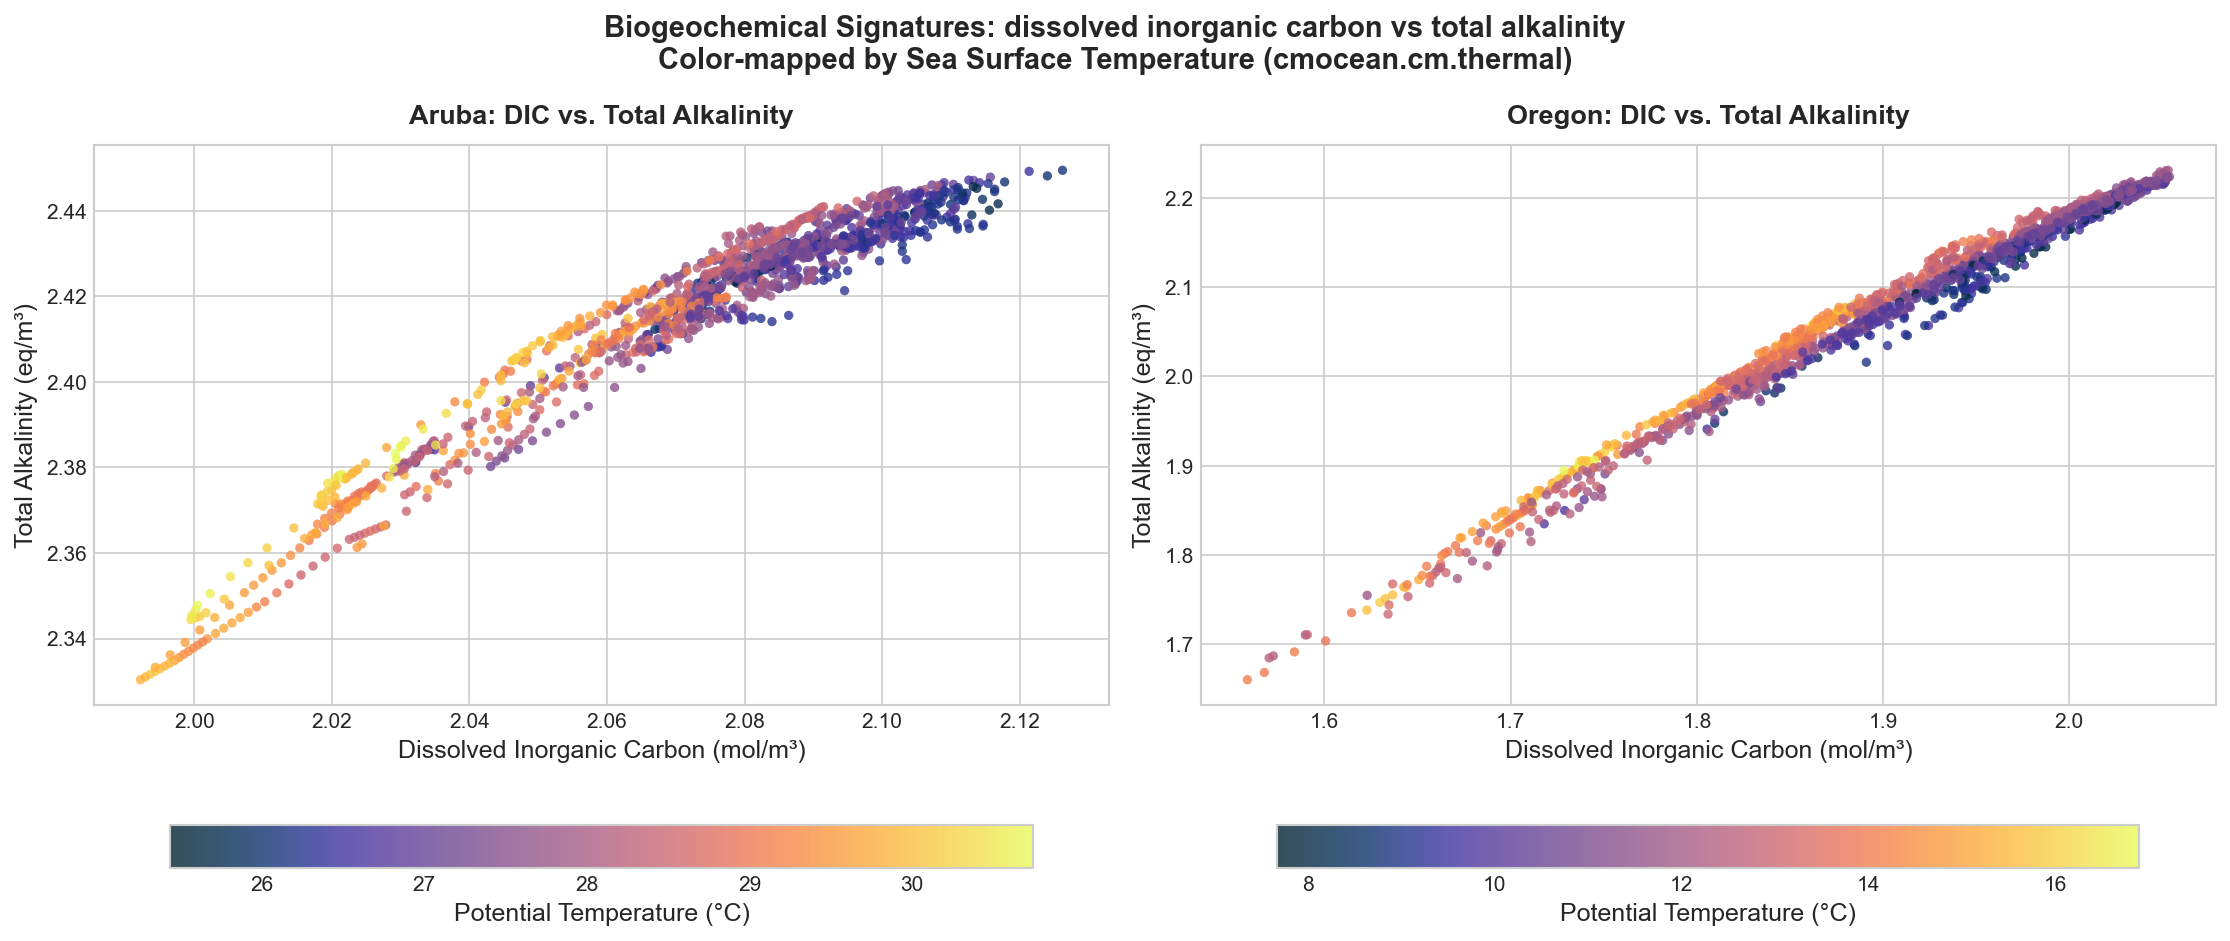

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), dpi=150, sharey=False)

# Aruba: DIC vs. TA colored by SST
sc1 = ax1.scatter(df_aruba['dissic'], df_aruba['talk'], c=df_aruba['thetao'], 
                  cmap=cmocean.cm.thermal, s=20, alpha=0.8, edgecolor='none')
ax1.set_title('Aruba: DIC vs. Total Alkalinity', fontweight='bold', pad=10)
ax1.set_xlabel('Dissolved Inorganic Carbon (mol/m³)')
ax1.set_ylabel('Total Alkalinity (eq/m³)')
cbar1 = fig.colorbar(sc1, ax=ax1, orientation='horizontal', pad=0.15, shrink=0.85)
cbar1.set_label('Potential Temperature (°C)')

# Oregon: DIC vs. TA colored by SST
sc2 = ax2.scatter(df_oregon['dissic'], df_oregon['talk'], c=df_oregon['thetao'], 
                  cmap=cmocean.cm.thermal, s=20, alpha=0.8, edgecolor='none')
ax2.set_title('Oregon: DIC vs. Total Alkalinity', fontweight='bold', pad=10)
ax2.set_xlabel('Dissolved Inorganic Carbon (mol/m³)')
ax2.set_ylabel('Total Alkalinity (eq/m³)')
cbar2 = fig.colorbar(sc2, ax=ax2, orientation='horizontal', pad=0.15, shrink=0.85)
cbar2.set_label('Potential Temperature (°C)')

fig.suptitle('Biogeochemical Signatures: dissolved inorganic carbon vs total alkalinity\nColor-mapped by Sea Surface Temperature (cmocean.cm.thermal)', 
             fontweight='bold', fontsize=14, y=0.98)

plt.tight_layout()
plt.show()